<a href="https://colab.research.google.com/github/zeko-1/2026-NVIDIA/blob/main/FInalProjectDataWrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Wrangling and EDA**

### Install & Import Libraries

In [5]:
# IMPORT LIBRARIES
import pandas as pd  # used for data manipulation (tables, cleaning)
import numpy as np   # used for numerical operations
import matplotlib.pyplot as plt  # basic plotting
import seaborn as sns  # advanced visualization
from IPython.display import display

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


### Upload & Load the Raw Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = "/content/drive/MyDrive/DataProject/online_learning_engagement_dataset (1).csv"

In [6]:
# Load dataset from Google Drive
df = pd.read_csv(file_path)

print("=" * 60)
print("RAW DATASET — INITIAL OVERVIEW")
print("=" * 60)
print(f"Shape     : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns   : {list(df.columns)}")
print()
display(df.head(5))

RAW DATASET — INITIAL OVERVIEW
Shape     : 50,000 rows × 18 columns
Columns   : ['student_id', 'age', 'gender', 'country', 'device_type', 'internet_speed_mbps', 'study_hours_weekly', 'login_frequency_weekly', 'avg_session_duration_min', 'video_watch_time_min', 'assignments_submitted', 'forum_posts', 'quiz_attempts', 'avg_quiz_score', 'attendance_rate', 'engagement_score', 'final_grade', 'dropout']



,student_id,age,gender,country,device_type,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade,dropout
0,1,24,Female,USA,Laptop,44.70,15.92,10,40.05,294.10,3,4,6,46.69,0.93,8.05,22.45,0
1,2,37,Female,Germany,Tablet,61.10,6.37,8,32.44,400.40,7,14,5,62.65,0.59,6.31,39.75,1
2,3,46,Female,Australia,Tablet,43.10,6.64,7,43.61,190.24,1,14,5,58.42,0.43,4.14,31.06,1
3,4,32,Male,India,Tablet,26.99,10.91,5,30.70,370.45,3,1,2,61.21,0.65,6.13,41.30,0
4,5,28,Male,India,Laptop,52.28,7.41,6,47.40,151.34,4,4,6,74.92,0.55,4.98,39.15,1


In [ ]:
# Check dataset shape (rows, columns)
df.shape

# Show column names
df.columns

Index(['student_id', 'age', 'gender', 'country', 'device_type',
       'internet_speed_mbps', 'study_hours_weekly', 'login_frequency_weekly',
       'avg_session_duration_min', 'video_watch_time_min',
       'assignments_submitted', 'forum_posts', 'quiz_attempts',
       'avg_quiz_score', 'attendance_rate', 'engagement_score', 'final_grade',
       'dropout'],
      dtype='object')

In [ ]:
# Check data types and missing values
df.info()

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                50000 non-null  int64  
 1   age                       50000 non-null  int64  
 2   gender                    50000 non-null  object 
 3   country                   50000 non-null  object 
 4   device_type               50000 non-null  object 
 5   internet_speed_mbps       50000 non-null  float64
 6   study_hours_weekly        50000 non-null  float64
 7   login_frequency_weekly    50000 non-null  int64  
 8   avg_session_duration_min  50000 non-null  float64
 9   video_watch_time_min      50000 non-null  float64
 10  assignments_submitted     50000 non-null  int64  
 11  forum_posts               50000 non-null  int64  
 12  quiz_attempts             50000 non-null  int64  
 13  avg_quiz_score            50000 non-null  float64
 14  attend

,student_id,age,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade,dropout
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,25000.500000,33.539960,49.996111,10.009115,7.498780,40.044473,299.748579,4.486120,6.985980,4.003100,70.018199,0.700335,6.199321,36.854200,0.32412
std,14433.901067,9.188219,14.992648,4.000621,4.026195,14.966684,119.331233,2.872367,4.325459,1.998742,15.057111,0.173304,1.510398,9.012627,0.46805
min,1.000000,18.000000,-7.300000,-5.790000,1.000000,-19.874917,-237.960893,0.000000,0.000000,1.000000,1.940000,0.400000,-0.353095,-0.173269,0.00000
25%,12500.750000,26.000000,39.920000,7.310000,4.000000,29.986016,219.140815,2.000000,3.000000,2.000000,59.850000,0.550000,5.174603,30.765320,0.00000
50%,25000.500000,34.000000,50.050000,9.995000,8.000000,40.078174,299.620686,4.000000,7.000000,4.000000,70.000000,0.700000,6.200308,36.846286,0.00000
75%,37500.250000,41.000000,60.090000,12.680000,11.000000,50.159928,380.161206,7.000000,11.000000,6.000000,80.130000,0.850000,7.216701,42.936420,1.00000
max,50000.000000,49.000000,111.170000,25.540000,14.000000,108.765278,778.595742,9.000000,14.000000,7.000000,137.490000,1.000000,12.620085,73.717902,1.00000


# **Data Cleaning**

### Check & Fix Data Types

In [9]:
# Expected types
expected_types = {
    'student_id'               : 'int64',
    'age'                      : 'int64',
    'gender'                   : 'object',
    'country'                  : 'object',
    'device_type'              : 'object',
    'internet_speed_mbps'      : 'float64',
    'study_hours_weekly'       : 'float64',
    'login_frequency_weekly'   : 'int64',
    'avg_session_duration_min' : 'float64',
    'video_watch_time_min'     : 'float64',
    'assignments_submitted'    : 'int64',
    'forum_posts'              : 'int64',
    'quiz_attempts'            : 'int64',
    'avg_quiz_score'           : 'float64',
    'attendance_rate'          : 'float64',
    'engagement_score'         : 'float64',
    'final_grade'              : 'float64',
    'dropout'                  : 'int64',
}

print("\n📋 Data Type Validation:")
type_issues = []
for col, expected in expected_types.items():
    actual = str(df[col].dtype)
    status = "✅" if actual == expected else "⚠️  MISMATCH"
    if actual != expected:
        type_issues.append(col)
    print(f"  {col:<30} Expected: {expected:<10}  Actual: {actual:<10}  {status}")

# Fix: ensure categorical columns are stored as object/string
for col in ['gender', 'country', 'device_type']:
    df[col] = df[col].astype(str).str.strip()

# Fix: ensure dropout is integer binary
df['dropout'] = df['dropout'].astype(int)

print(f"\n🔧 Decision: Categorical columns cast to str and stripped of whitespace.")
print(f"   dropout column cast to int.")
print(f"\n✅ Data types check complete. Issues found: {len(type_issues)}")


📋 Data Type Validation:
  student_id                     Expected: int64       Actual: int64       ✅
  age                            Expected: int64       Actual: int64       ✅
  gender                         Expected: object      Actual: object      ✅
  country                        Expected: object      Actual: object      ✅
  device_type                    Expected: object      Actual: object      ✅
  internet_speed_mbps            Expected: float64     Actual: float64     ✅
  study_hours_weekly             Expected: float64     Actual: float64     ✅
  login_frequency_weekly         Expected: int64       Actual: int64       ✅
  avg_session_duration_min       Expected: float64     Actual: float64     ✅
  video_watch_time_min           Expected: float64     Actual: float64     ✅
  assignments_submitted          Expected: int64       Actual: int64       ✅
  forum_posts                    Expected: int64       Actual: int64       ✅
  quiz_attempts                  Expected: int64   

### Check Missing Values

In [10]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0
      else "✅ No missing values found in any column.")

# Decision note
print("\n📋 Decision: No missing values detected. No imputation required.")

✅ No missing values found in any column.

📋 Decision: No missing values detected. No imputation required.


### Check Duplicate Records

In [13]:
full_dupes       = df.duplicated().sum()
student_id_dupes = df['student_id'].duplicated().sum()

print(f"  Fully duplicate rows        : {full_dupes}")
print(f"  Duplicate student_id values : {student_id_dupes}")

if full_dupes > 0:
    df = df.drop_duplicates()
    print(f"\n🔧 Decision: {full_dupes} duplicate rows removed.")
else:
    print("\n✅ No duplicate records found. No rows removed.")

  Fully duplicate rows        : 0
  Duplicate student_id values : 0

✅ No duplicate records found. No rows removed.


### Detect Negative Values (with Chart)

  internet_speed_mbps            Negative count: 27
  study_hours_weekly             Negative count: 303
  avg_session_duration_min       Negative count: 191
  video_watch_time_min           Negative count: 279
  engagement_score               Negative count: 2
  final_grade                    Negative count: 1
  avg_quiz_score                 Negative count: 0



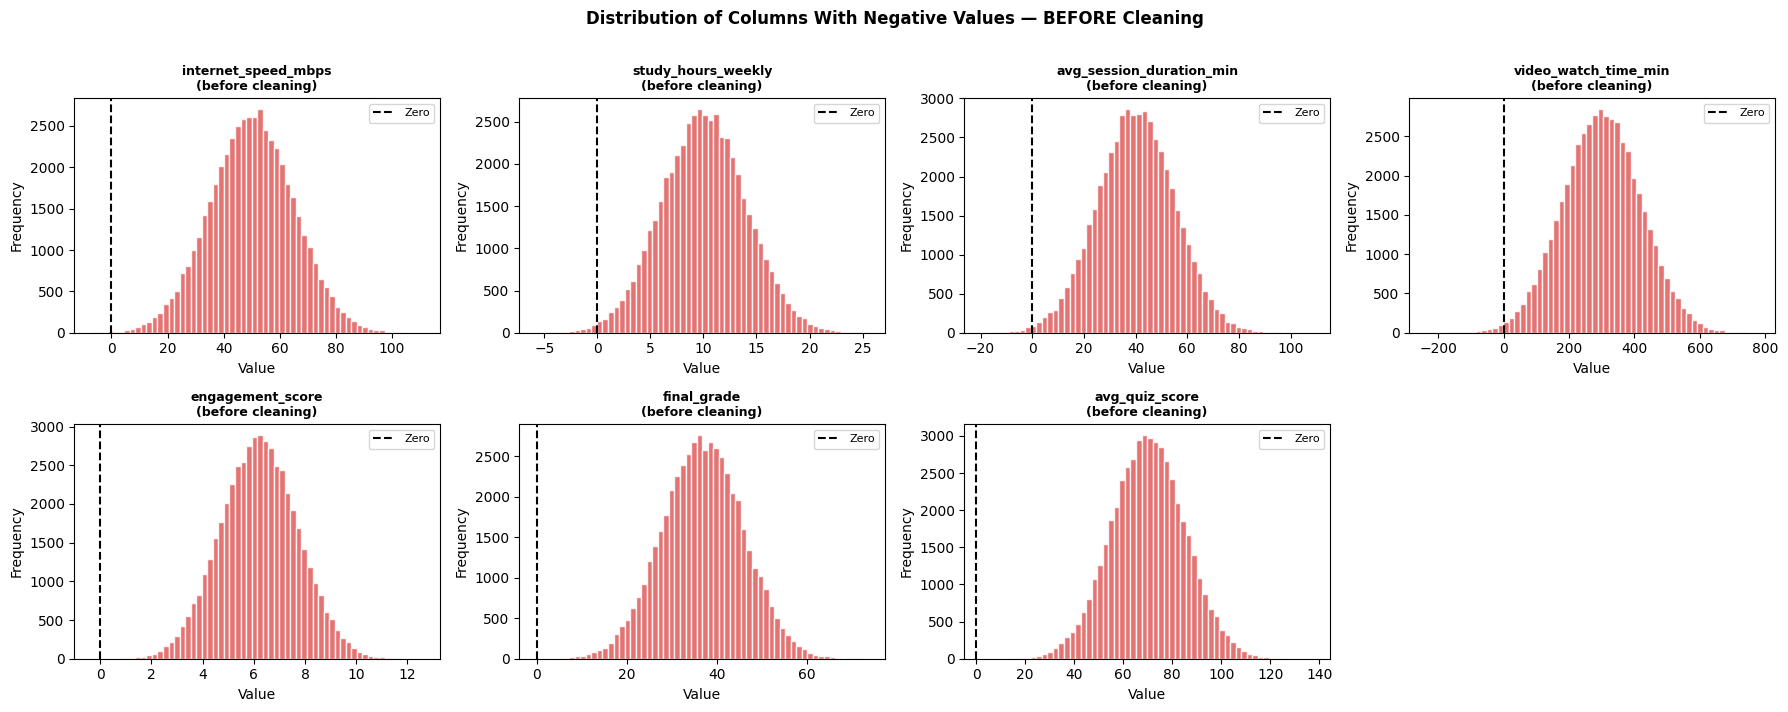

📊 Chart saved: before_cleaning_distributions.png


In [14]:
# Columns that physically cannot be negative
non_negative_cols = [
    'internet_speed_mbps',
    'study_hours_weekly',
    'avg_session_duration_min',
    'video_watch_time_min',
    'engagement_score',
    'final_grade',
    'avg_quiz_score',
]

neg_summary = {}
for col in non_negative_cols:
    count = (df[col] < 0).sum()
    neg_summary[col] = count
    print(f"  {col:<30} Negative count: {count}")

print()

# Visualise negative values before cleaning
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(non_negative_cols):
    axes[i].hist(df[col], bins=60, color='#E05C5C', edgecolor='white', alpha=0.85)
    axes[i].axvline(0, color='black', linewidth=1.5, linestyle='--', label='Zero')
    axes[i].set_title(f'{col}\n(before cleaning)', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)
axes[-1].set_visible(False)
plt.suptitle('Distribution of Columns With Negative Values — BEFORE Cleaning',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('before_cleaning_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved: before_cleaning_distributions.png")

### Fix Negative Values

In [15]:
# Group A: Physical measurements — take absolute value
abs_cols = [
    'internet_speed_mbps',
    'study_hours_weekly',
    'avg_session_duration_min',
    'video_watch_time_min',
]
for col in abs_cols:
    n = (df[col] < 0).sum()
    if n > 0:
        df[col] = df[col].abs()
        print(f'  🔧 {col:<30} {n:>4} negatives → converted to absolute value')
    else:
        print(f'  ✅ {col:<30} No negatives found')

print()

# Group B: Score/grade columns — floor at 0
floor_cols = ['engagement_score', 'final_grade']
for col in floor_cols:
    n = (df[col] < 0).sum()
    if n > 0:
        df.loc[df[col] < 0, col] = 0.0
        print(f'  🔧 {col:<30} {n:>4} negatives → set to 0')
    else:
        print(f'  ✅ {col:<30} No negatives found')

print("""
📋 Reasoning:
  • internet_speed_mbps, study_hours_weekly, avg_session_duration_min,
    video_watch_time_min — physical measurements. A negative value is
    impossible and likely a data-entry sign error. Absolute value
    preserves the magnitude.
  • engagement_score, final_grade — scores cannot be below zero.
    Negative entries are set to 0 (minimum valid value).
""")

  🔧 internet_speed_mbps              27 negatives → converted to absolute value
  🔧 study_hours_weekly              303 negatives → converted to absolute value
  🔧 avg_session_duration_min        191 negatives → converted to absolute value
  🔧 video_watch_time_min            279 negatives → converted to absolute value

  🔧 engagement_score                  2 negatives → set to 0
  🔧 final_grade                       1 negatives → set to 0

📋 Reasoning:
  • internet_speed_mbps, study_hours_weekly, avg_session_duration_min,
    video_watch_time_min — physical measurements. A negative value is
    impossible and likely a data-entry sign error. Absolute value
    preserves the magnitude.
  • engagement_score, final_grade — scores cannot be below zero.
    Negative entries are set to 0 (minimum valid value).



### Fix Out-of-Range Values

In [16]:
# avg_quiz_score must be in [0, 100]
above_100 = (df['avg_quiz_score'] > 100).sum()
below_0   = (df['avg_quiz_score'] < 0).sum()
print(f'  avg_quiz_score > 100 : {above_100}')
print(f'  avg_quiz_score < 0   : {below_0}')
df['avg_quiz_score'] = df['avg_quiz_score'].clip(lower=0, upper=100)
print(f'  🔧 avg_quiz_score capped to [0, 100]')

# attendance_rate must be in [0, 1]
above_1 = (df['attendance_rate'] > 1).sum()
below_0 = (df['attendance_rate'] < 0).sum()
print(f'\n  attendance_rate > 1  : {above_1}')
print(f'  attendance_rate < 0  : {below_0}')
df['attendance_rate'] = df['attendance_rate'].clip(lower=0, upper=1)
print(f'  ✅ attendance_rate within valid [0, 1] range')

print("""
📋 Reasoning:
  • avg_quiz_score represents a percentage. Values above 100 are
    logically impossible. Clipping at 100 retains the student record
    while correcting the erroneous entry.
  • attendance_rate is a proportion (0 = never, 1 = always).
    Values outside [0, 1] are invalid.
""")

  avg_quiz_score > 100 : 1183
  avg_quiz_score < 0   : 0
  🔧 avg_quiz_score capped to [0, 100]

  attendance_rate > 1  : 0
  attendance_rate < 0  : 0
  ✅ attendance_rate within valid [0, 1] range

📋 Reasoning:
  • avg_quiz_score represents a percentage. Values above 100 are
    logically impossible. Clipping at 100 retains the student record
    while correcting the erroneous entry.
  • attendance_rate is a proportion (0 = never, 1 = always).
    Values outside [0, 1] are invalid.



### Check Categorical Consistency

In [17]:
for col in ['gender', 'country', 'device_type', 'dropout']:
    print(f'  {col:<20} Unique values: {sorted(df[col].unique())}')

print()
expected_map = {
    'gender'     : {'Female', 'Male'},
    'country'    : {'USA', 'India', 'UK', 'Germany', 'Australia', 'Canada'},
    'device_type': {'Laptop', 'Tablet', 'Mobile'},
}
for col, expected in expected_map.items():
    unexpected = set(df[col].unique()) - expected
    if unexpected:
        print(f'  ⚠️  {col}: unexpected values → {unexpected}')
    else:
        print(f'  ✅ {col}: all values are valid')

if not set(df['dropout'].unique()).issubset({0, 1}):
    print('  ⚠️  dropout: unexpected values found')
else:
    print('  ✅ dropout: valid binary values (0 = retained, 1 = dropped out)')

print('\n📋 Decision: No unexpected categories found. No corrections needed.')

  gender               Unique values: ['Female', 'Male']
  country              Unique values: ['Australia', 'Canada', 'Germany', 'India', 'UK', 'USA']
  device_type          Unique values: ['Laptop', 'Mobile', 'Tablet']
  dropout              Unique values: [np.int64(0), np.int64(1)]

  ✅ gender: all values are valid
  ✅ country: all values are valid
  ✅ device_type: all values are valid
  ✅ dropout: valid binary values (0 = retained, 1 = dropped out)

📋 Decision: No unexpected categories found. No corrections needed.


### Check Logical Inconsistencies

In [18]:
print('=' * 60)
print('STEP 8 — LOGICAL INCONSISTENCY CHECKS')
print('=' * 60)

issues_found = 0

checks = [
    ('quiz_attempts < 1',            (df['quiz_attempts'] < 1).sum()),
    ('login_frequency_weekly < 1',   (df['login_frequency_weekly'] < 1).sum()),
    ('age outside [18, 70]',         ((df['age'] < 18) | (df['age'] > 70)).sum()),
    ('assignments_submitted < 0',    (df['assignments_submitted'] < 0).sum()),
    ('forum_posts < 0',              (df['forum_posts'] < 0).sum()),
    ('engagement_score > 15',        (df['engagement_score'] > 15).sum()),
]

for label, count in checks:
    issues_found += count
    print(f'  {label:<35} : {count}')

print(f'\n  Total logical inconsistencies : {issues_found}')
print('  ✅ No further corrections needed.' if issues_found == 0
      else '  🔧 Please review entries above.')

print("""
📋 Reasoning:
  • A student must have attempted at least 1 quiz to have a record.
  • Login frequency must be at least 1 (they are enrolled).
  • Age range [18–70] is realistic for adult online learners.
  • Activity counts (assignments, posts) cannot be negative.
""")

STEP 8 — LOGICAL INCONSISTENCY CHECKS
  quiz_attempts < 1                   : 0
  login_frequency_weekly < 1          : 0
  age outside [18, 70]                : 0
  assignments_submitted < 0           : 0
  forum_posts < 0                     : 0
  engagement_score > 15               : 0

  Total logical inconsistencies : 0
  ✅ No further corrections needed.

📋 Reasoning:
  • A student must have attempted at least 1 quiz to have a record.
  • Login frequency must be at least 1 (they are enrolled).
  • Age range [18–70] is realistic for adult online learners.
  • Activity counts (assignments, posts) cannot be negative.



### Round Float Columns

In [19]:
float_cols = [
    'internet_speed_mbps', 'study_hours_weekly',
    'avg_session_duration_min', 'video_watch_time_min',
    'avg_quiz_score', 'attendance_rate',
    'engagement_score', 'final_grade'
]
for col in float_cols:
    df[col] = df[col].round(2)
    print(f'  ✅ {col} rounded to 2 decimal places')

print("""
📋 Reasoning:
  Excessive decimal precision (e.g. 40.052752) adds no analytical
  value. Rounding to 2 d.p. retains meaningful precision for scores,
  durations, and rates.
""")

  ✅ internet_speed_mbps rounded to 2 decimal places
  ✅ study_hours_weekly rounded to 2 decimal places
  ✅ avg_session_duration_min rounded to 2 decimal places
  ✅ video_watch_time_min rounded to 2 decimal places
  ✅ avg_quiz_score rounded to 2 decimal places
  ✅ attendance_rate rounded to 2 decimal places
  ✅ engagement_score rounded to 2 decimal places
  ✅ final_grade rounded to 2 decimal places

📋 Reasoning:
  Excessive decimal precision (e.g. 40.052752) adds no analytical
  value. Rounding to 2 d.p. retains meaningful precision for scores,
  durations, and rates.



### Post-Cleaning Validation

In [20]:
validations = {
    'Rows remaining'            : len(df),
    'Missing values'            : df.isnull().sum().sum(),
    'Duplicate rows'            : df.duplicated().sum(),
    'Negative study_hours'      : (df['study_hours_weekly'] < 0).sum(),
    'Negative session_duration' : (df['avg_session_duration_min'] < 0).sum(),
    'Negative video_watch_time' : (df['video_watch_time_min'] < 0).sum(),
    'Negative internet_speed'   : (df['internet_speed_mbps'] < 0).sum(),
    'Negative engagement_score' : (df['engagement_score'] < 0).sum(),
    'Negative final_grade'      : (df['final_grade'] < 0).sum(),
    'quiz_score > 100'          : (df['avg_quiz_score'] > 100).sum(),
    'attendance_rate > 1'       : (df['attendance_rate'] > 1).sum(),
}

for check, result in validations.items():
    if check == 'Rows remaining':
        print(f'  {check:<35} : {result:,}')
    else:
        status = '✅' if result == 0 else '❌ ISSUE'
        print(f'  {check:<35} : {result}  {status}')

  Rows remaining                      : 50,000
  Missing values                      : 0  ✅
  Duplicate rows                      : 0  ✅
  Negative study_hours                : 0  ✅
  Negative session_duration           : 0  ✅
  Negative video_watch_time           : 0  ✅
  Negative internet_speed             : 0  ✅
  Negative engagement_score           : 0  ✅
  Negative final_grade                : 0  ✅
  quiz_score > 100                    : 0  ✅
  attendance_rate > 1                 : 0  ✅


### Before vs After Distribution Charts

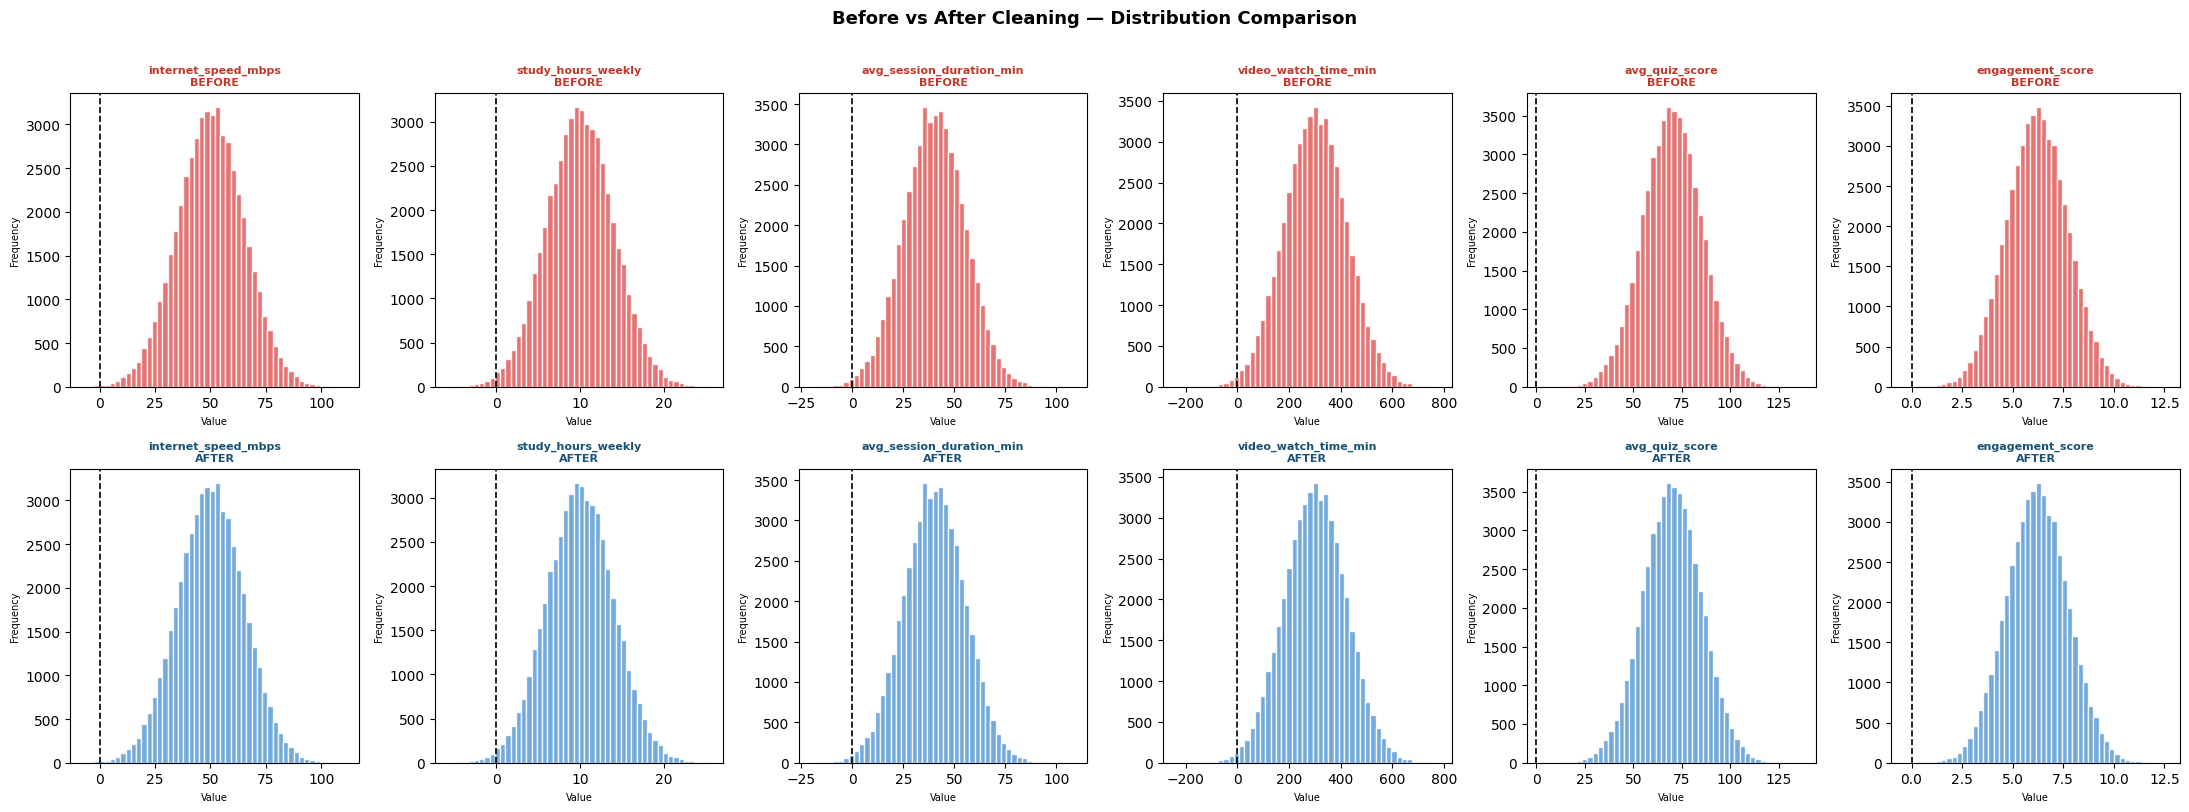

📊 Chart saved: before_vs_after_cleaning.png


In [24]:
df_raw = pd.read_csv(file_path)

compare_cols = [
    'internet_speed_mbps', 'study_hours_weekly',
    'avg_session_duration_min', 'video_watch_time_min',
    'avg_quiz_score', 'engagement_score'
]

fig, axes = plt.subplots(2, 6, figsize=(22, 8))

for i, col in enumerate(compare_cols):
    axes[0, i].hist(df_raw[col].dropna(), bins=50, color='#E05C5C', edgecolor='white', alpha=0.85)
    axes[0, i].axvline(0, color='black', linewidth=1.2, linestyle='--')
    axes[0, i].set_title(f'{col}\nBEFORE', fontsize=8, fontweight='bold', color='#C0392B')
    axes[0, i].set_xlabel('Value', fontsize=7)
    axes[0, i].set_ylabel('Frequency', fontsize=7)

    axes[1, i].hist(df[col].dropna(), bins=50, color='#5B9BD5', edgecolor='white', alpha=0.85)
    axes[1, i].axvline(0, color='black', linewidth=1.2, linestyle='--')
    axes[1, i].set_title(f'{col}\nAFTER', fontsize=8, fontweight='bold', color='#1A5276')
    axes[1, i].set_xlabel('Value', fontsize=7)
    axes[1, i].set_ylabel('Frequency', fontsize=7)

plt.suptitle('Before vs After Cleaning — Distribution Comparison',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('before_vs_after_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved: before_vs_after_cleaning.png')

### Cleaning Summary Table

In [25]:
summary = pd.DataFrame([
    ['internet_speed_mbps',       'Negative values',        27,   'Converted to absolute value', 'Physical speed cannot be negative'],
    ['study_hours_weekly',        'Negative values',       303,   'Converted to absolute value', 'Hours cannot be negative'],
    ['avg_session_duration_min',  'Negative values',       191,   'Converted to absolute value', 'Duration cannot be negative'],
    ['video_watch_time_min',      'Negative values',       279,   'Converted to absolute value', 'Watch time cannot be negative'],
    ['engagement_score',          'Negative values',         2,   'Set to 0',                    'Score floor is 0'],
    ['final_grade',               'Negative values',         1,   'Set to 0',                    'Grade floor is 0'],
    ['avg_quiz_score',            'Values > 100',         1183,   'Capped at 100',               'Score ceiling is 100%'],
    ['attendance_rate',           'Range check',             0,   'No action needed',            'All values within [0, 1]'],
    ['Duplicate rows',            'Full row duplicates',     0,   'No action needed',            'No duplicates found'],
    ['Missing values',            'NaN / null cells',        0,   'No action needed',            'Dataset is complete'],
], columns=['Column', 'Issue Type', 'Count', 'Action Taken', 'Reasoning'])

display(summary)
print(f'\nTotal records affected : {303+191+279+2+1+1183:,}')
print(f'Total records retained : {len(df):,}')
print(f'Records removed        : 0')

,Column,Issue Type,Count,Action Taken,Reasoning
0,internet_speed_mbps,Negative values,27,Converted to absolute value,Physical speed cannot be negative
1,study_hours_weekly,Negative values,303,Converted to absolute value,Hours cannot be negative
2,avg_session_duration_min,Negative values,191,Converted to absolute value,Duration cannot be negative
3,video_watch_time_min,Negative values,279,Converted to absolute value,Watch time cannot be negative
4,engagement_score,Negative values,2,Set to 0,Score floor is 0
5,final_grade,Negative values,1,Set to 0,Grade floor is 0
6,avg_quiz_score,Values > 100,1183,Capped at 100,Score ceiling is 100%
7,attendance_rate,Range check,0,No action needed,"All values within [0, 1]"
8,Duplicate rows,Full row duplicates,0,No action needed,No duplicates found
9,Missing values,NaN / null cells,0,No action needed,Dataset is complete



Total records affected : 1,959
Total records retained : 50,000
Records removed        : 0


### Final Cleaned Dataset Overview

In [26]:
print('=' * 60)
print('FINAL CLEANED DATASET — OVERVIEW')
print('=' * 60)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
display(df.describe().round(2))
print()
display(df.head(5))

FINAL CLEANED DATASET — OVERVIEW
Shape: 50,000 rows × 18 columns



,student_id,age,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade,dropout
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,25000.50,33.54,50.00,10.01,7.50,40.04,299.75,4.49,6.99,4.00,70.02,0.70,6.20,36.85,0.32
std,14433.90,9.19,14.99,4.00,4.03,14.97,119.33,2.87,4.33,2.00,15.06,0.17,1.51,9.01,0.47
min,1.00,18.00,-7.30,-5.79,1.00,-19.87,-237.96,0.00,0.00,1.00,1.94,0.40,-0.35,-0.17,0.00
25%,12500.75,26.00,39.92,7.31,4.00,29.99,219.14,2.00,3.00,2.00,59.85,0.55,5.17,30.77,0.00
50%,25000.50,34.00,50.05,10.00,8.00,40.08,299.62,4.00,7.00,4.00,70.00,0.70,6.20,36.85,0.00
75%,37500.25,41.00,60.09,12.68,11.00,50.16,380.16,7.00,11.00,6.00,80.13,0.85,7.22,42.94,1.00
max,50000.00,49.00,111.17,25.54,14.00,108.77,778.60,9.00,14.00,7.00,137.49,1.00,12.62,73.72,1.00


,student_id,age,gender,country,device_type,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade,dropout
0,1,24,Female,USA,Laptop,44.70,15.92,10,40.05,294.10,3,4,6,46.69,0.93,8.05,22.45,0
1,2,37,Female,Germany,Tablet,61.10,6.37,8,32.44,400.40,7,14,5,62.65,0.59,6.31,39.75,1
2,3,46,Female,Australia,Tablet,43.10,6.64,7,43.61,190.24,1,14,5,58.42,0.43,4.14,31.06,1
3,4,32,Male,India,Tablet,26.99,10.91,5,30.70,370.45,3,1,2,61.21,0.65,6.13,41.30,0
4,5,28,Male,India,Laptop,52.28,7.41,6,47.40,151.34,4,4,6,74.92,0.55,4.98,39.15,1


# **Filtering and Sorting**

In [ ]:
# Filtering
# 1. High engagement students
high_engagement = df[df['engagement_score'] > 7]

# 2. Dropout students
dropouts = df[df['dropout'] == 1]

# 3. Active students
active_students = df[df['study_hours_weekly'] > 10]

# 4. Inactive students
inactive_students = df[df['study_hours_weekly'] <= 10]

In [ ]:
# Sorting
# 1. Sorting: students by final grade (highest to lowest)
df_sorted_grade = df.sort_values(by='final_grade', ascending=False)

# 2. Sorting: students by engagement score (highest to lowest)
df_sorted_engagement = df.sort_values(by='engagement_score', ascending=False)

# **Outlier Analysis**

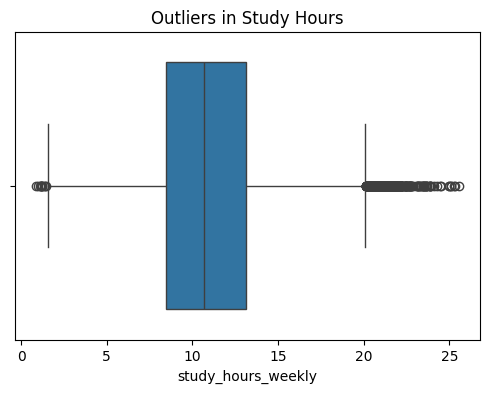

In [ ]:
# Outliers (IQR METHOD)
Q1 = df['study_hours_weekly'].quantile(0.25)
Q3 = df['study_hours_weekly'].quantile(0.75)

# Calculate IQR (Interquartile Range)
IQR = Q3 - Q1

# Define lower and upper bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['study_hours_weekly'] < lower) | (df['study_hours_weekly'] > upper)]

# Visualize outliers using boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['study_hours_weekly'])
plt.title("Outliers in Study Hours")
plt.show()

# Remove outliers
# Outliers were removed because they were considered unrealistic values that could distort the analysis
df = df[(df['study_hours_weekly'] >= lower) & (df['study_hours_weekly'] <= upper)]

# **Feature Engineering**

In [ ]:
# Feature Engineering
# 1. Engagement Category
def engagement_level(score):
    if score < 4:
        return "Low"
    elif score < 7:
        return "Medium"
    else:
        return "High"

df['engagement_category'] = df['engagement_score'].apply(engagement_level)

# 2. Study Efficiency
df['study_efficiency'] = df['final_grade'] / df['study_hours_weekly']

# 3. Activity Index
df['activity_index'] = df['login_frequency_weekly'] + df['forum_posts']

# 4. Performance Band
def performance_band(grade):
    if grade >= 85:
        return "A"
    elif grade >= 70:
        return "B"
    elif grade >= 50:
        return "C"
    else:
        return "D"

df['performance_band'] = df['final_grade'].apply(performance_band)

# **Normalization**

In [ ]:
from sklearn.preprocessing import MinMaxScaler  # import scaler

scaler = MinMaxScaler()  # initialize scaler

# Normalize study hours and engagement score (scale between 0 and 1)
df[['study_hours_norm','engagement_norm']] = scaler.fit_transform(
    df[['study_hours_weekly','engagement_score']]
)

# **Exploratory Data Analysis**

In [ ]:
df.describe()

,student_id,age,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade,dropout,study_minutes,study_efficiency,activity_index,study_hours_norm,engagement_norm
count,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000,42684.000000
mean,25010.161419,33.523451,49.973641,10.816388,7.490910,40.173818,288.826177,4.476877,6.996322,3.996580,69.993943,0.700372,6.383738,36.900339,0.323517,648.983272,3.802214,14.487232,0.499265,0.498361
std,14418.329481,9.193938,15.028224,3.310952,4.026502,14.752981,112.535262,2.875833,4.321104,1.999763,15.052046,0.173101,1.408929,9.018817,0.467824,198.657114,1.777583,5.929843,0.178777,0.132502
min,1.000000,18.000000,-7.300000,1.570000,1.000000,0.003112,0.605899,0.000000,0.000000,1.000000,1.940000,0.400000,1.084541,-0.173269,0.000000,94.200000,-0.021286,1.000000,0.000000,0.000000
25%,12562.750000,26.000000,39.900000,8.420000,4.000000,30.055820,210.837328,2.000000,3.000000,2.000000,59.830000,0.550000,5.414384,30.806009,0.000000,505.200000,2.644492,10.000000,0.369870,0.407198
50%,25013.500000,33.000000,50.000000,10.630000,7.000000,40.118119,288.323588,4.000000,7.000000,4.000000,69.980000,0.700000,6.376614,36.893570,0.000000,637.800000,3.441951,14.000000,0.489201,0.497691
75%,37509.250000,41.000000,60.100000,13.040000,11.000000,50.172361,365.091993,7.000000,11.000000,6.000000,80.060000,0.850000,7.341841,42.997631,1.000000,782.400000,4.533175,19.000000,0.619330,0.588465
max,50000.000000,49.000000,111.170000,20.090000,14.000000,107.883224,765.449182,9.000000,14.000000,7.000000,137.490000,1.000000,11.717797,73.717902,1.000000,1205.400000,30.721954,28.000000,1.000000,1.000000


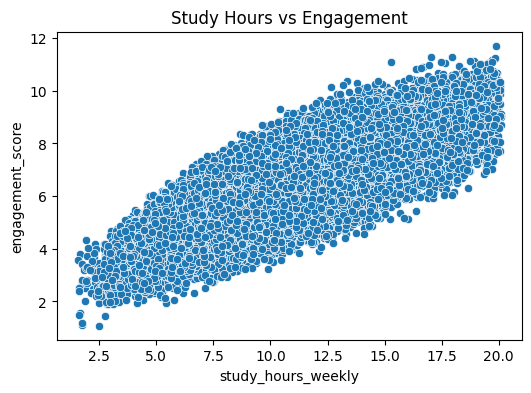

In [ ]:
# 1. Study Hours vs Engagement
plt.figure(figsize=(6,4))
sns.scatterplot(x='study_hours_weekly', y='engagement_score', data=df)
plt.title("Study Hours vs Engagement")
plt.show()

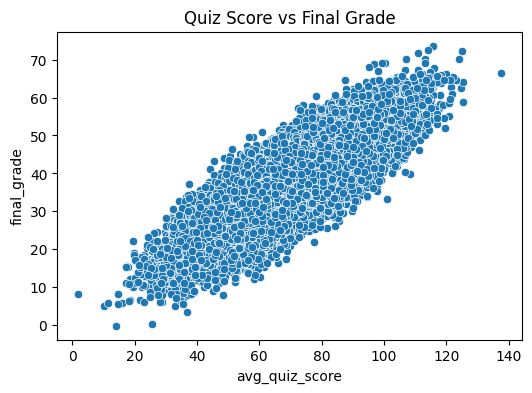

In [ ]:
# 2. Quiz Score vs Final Grade
plt.figure(figsize=(6,4))
sns.scatterplot(x='avg_quiz_score', y='final_grade', data=df)
plt.title("Quiz Score vs Final Grade")
plt.show()


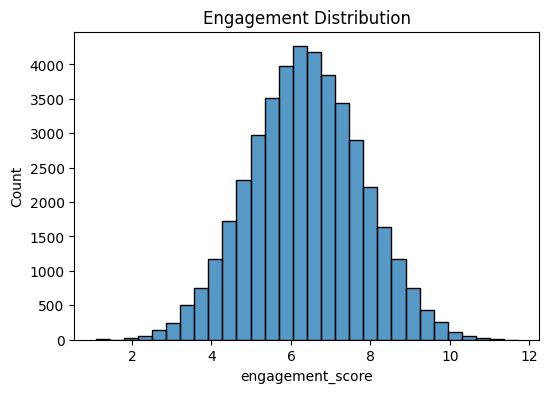

In [ ]:
# 3. Engagement Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['engagement_score'], bins=30)
plt.title("Engagement Distribution")
plt.show()

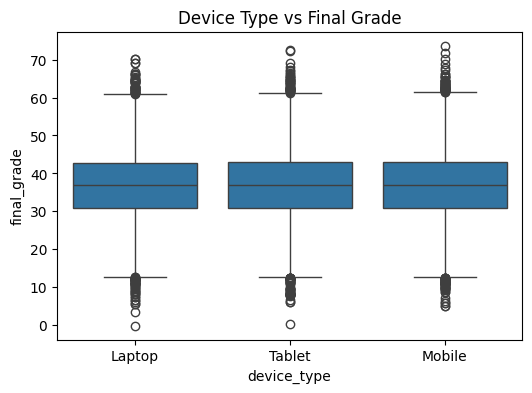

In [ ]:
# 4. Device Type vs Performance
plt.figure(figsize=(6,4))
sns.boxplot(x='device_type', y='final_grade', data=df)
plt.title("Device Type vs Final Grade")
plt.show()


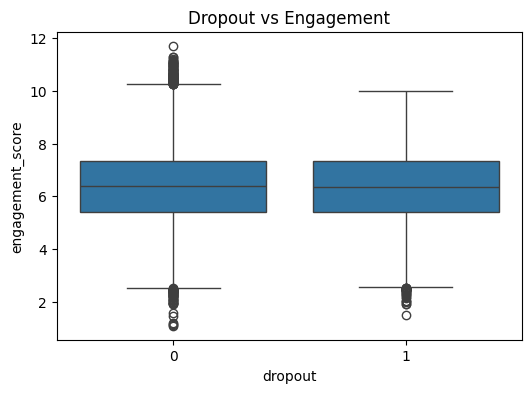

In [ ]:
# 5. Dropout vs Engagement
plt.figure(figsize=(6,4))
sns.boxplot(x='dropout', y='engagement_score', data=df)
plt.title("Dropout vs Engagement")
plt.show()

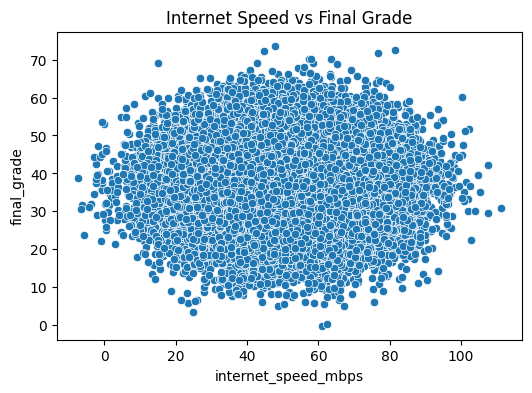

In [ ]:
# 6. internet_speed vs final_grade plot
plt.figure(figsize=(6,4))
sns.scatterplot(x='internet_speed_mbps', y='final_grade', data=df)
plt.title("Internet Speed vs Final Grade")
plt.show()

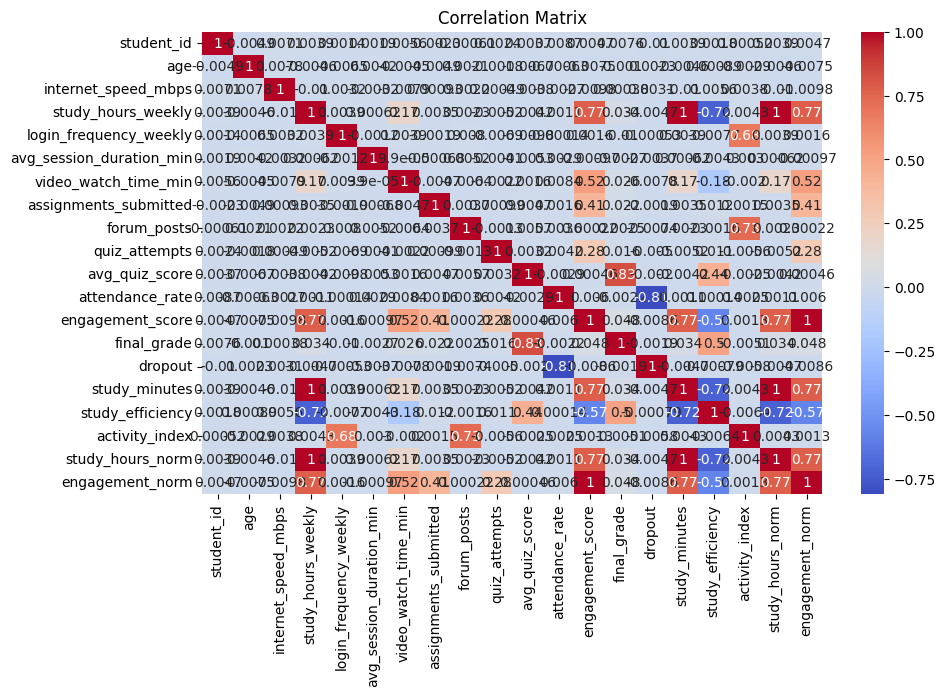

In [ ]:
# 7. Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# **Save and Export Cleaned Data**

In [31]:
# Save processed dataset for dashboard use
output_filename = '/content/drive/MyDrive/DataProject/cleaned_data.csv'
df.to_csv(output_filename, index=False)
print(f'✅ Cleaned dataset saved as: {output_filename}')

# Auto-download the file
from google.colab import files
files.download(output_filename)

✅ Cleaned dataset saved as: /content/drive/MyDrive/DataProject/cleaned_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>